California housing data
https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures
import gc
import sys
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/California-housing")
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.tool import (
    get_metrics,
    plot_true_vs_pred
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load the California housing data
cal = fetch_california_housing(as_frame=True)
X, y = cal.data, cal.target
feature_names = X.columns
print(feature_names)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [4]:
results = []

      Feature  Coefficent
0      MedInc    0.448675
1    HouseAge    0.009724
2    AveRooms   -0.123323
3   AveBedrms    0.783145
4  Population   -0.000002
5    AveOccup   -0.003526
6    Latitude   -0.419792
7   Longitude   -0.433708


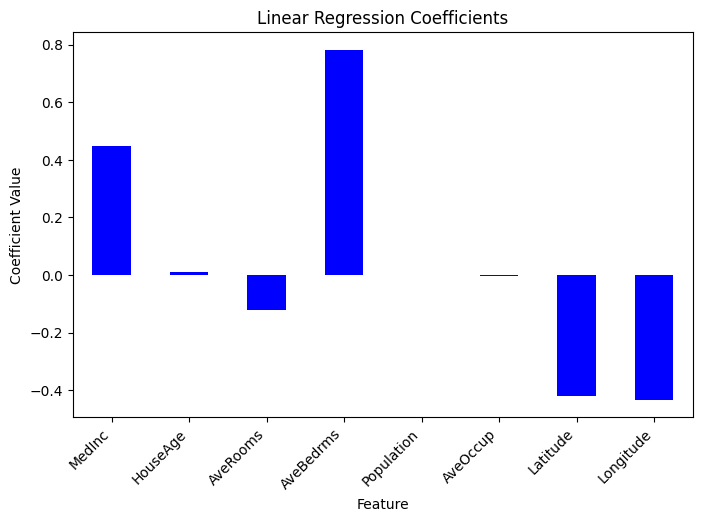

In [5]:
# regress the median house value for California districts on the eight predictor variables.
model=LinearRegression()
model.fit(X_train,y_train)

# print coefficients as table
coef_df=pd.DataFrame({
    "Feature": feature_names,
    "Coefficent": model.coef_
})
print(coef_df)

# Visualize feature coefficients as vertical bar chart
coef_df = coef_df.set_index("Feature")
coef_df.plot(kind="bar",figsize=(8,5),legend=False,color="blue")
plt.title("Linear Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Feature")
plt.xticks(rotation=45,ha="right")
plt.savefig(FIG_DIR / "linear_regression_coefficients.png")
plt.show()

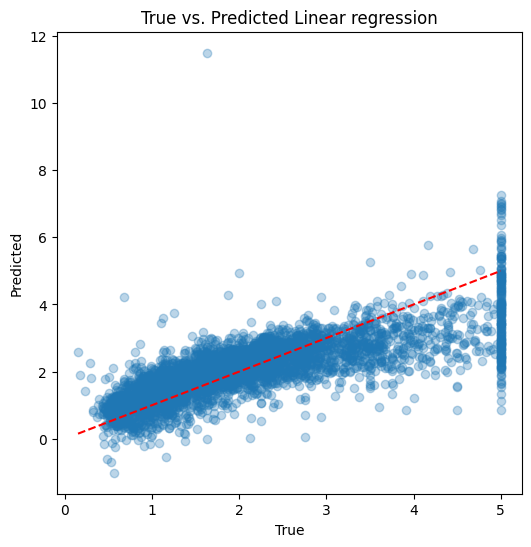

In [6]:
y_pred=model.predict(X_test)
y_train_pred=model.predict(X_train)

results.append(get_metrics(y_train, y_train_pred, "Linear regression", "Train"))
results.append(get_metrics(y_test, y_pred, "Linear regression",  "Test"))

plot_true_vs_pred(y_test, y_pred, "Linear regression")

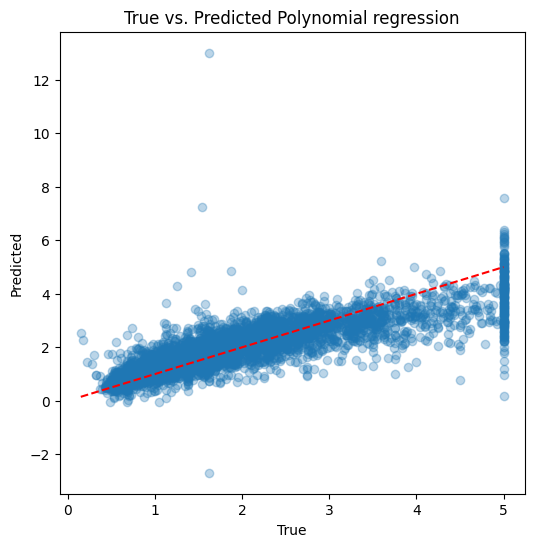

Best alpha: 10.0


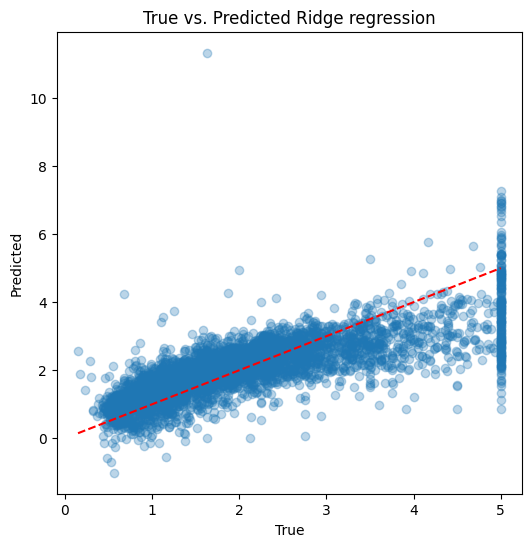

In [7]:
# polynomial regression
poly = PolynomialFeatures(degree=2,include_bias=False)
X_train_poly=poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly=LinearRegression()
model_poly.fit(X_train_poly,y_train)
y_pred_poly=model_poly.predict(X_test_poly)
y_train_pred_poly = model_poly.predict(X_train_poly)

results.append(get_metrics(y_train, y_train_pred_poly, "Polynomial regression", "Train"))
results.append(get_metrics(y_test, y_pred_poly, "Polynomial regression",  "Test"))

plot_true_vs_pred(y_test, y_pred_poly, "Polynomial regression")

# ridge regression
alphas=[0.01,0.1,1,10,100,1000]
model_ridge_cv=RidgeCV(alphas=alphas, scoring="r2", cv=10)
model_ridge_cv.fit(X_train,y_train)
print("Best alpha:",model_ridge_cv.alpha_)

model_ridge=Ridge(alpha=model_ridge_cv.alpha_)
model_ridge.fit(X_train,y_train)
y_pred_ridge=model_ridge.predict(X_test)
y_train_pred_ridge = model_ridge.predict(X_train)

results.append(get_metrics(y_train, y_train_pred_ridge, "Ridge regression", "Train"))
results.append(get_metrics(y_test, y_pred_ridge, "Ridge regression",  "Test"))

plot_true_vs_pred(y_test, y_pred_ridge, "Ridge regression")

In [8]:
results_df=pd.DataFrame(results)
results_df.to_csv(RESULTS_DIR / "results.csv",index=False)
results_df

,model,data,r^2,mae,mse,rmse
0,Linear regression,Train,0.612551,0.528628,0.517933,0.719676
1,Linear regression,Test,0.575788,0.533200,0.555892,0.745581
2,Polynomial regression,Train,0.685268,0.460838,0.420727,0.648634
3,Polynomial regression,Test,0.645682,0.467001,0.464302,0.681397
4,Ridge regression,Train,0.612545,0.528738,0.517942,0.719682
5,Ridge regression,Test,0.576437,0.533243,0.555041,0.745010
